# 05. 変数分離法 — 固有関数で解く

| 層 | セクション |
|---|---|
| Basic | 1. Big Picture 〜 4. Visualization |
| Applied | 5. 熱の解析解 〜 6. 波動の解析解 |
| Advanced | 11. Advanced Notes |

## 1. Big Picture

**変数分離法** は、解を空間部分と時間部分の積

$$
u(x, t) = X(x)\,T(t)
$$

と仮定して PDE を 2 つの ODE に分解する手法です。境界条件が空間部分 $X(x)$ の許される形(**固有関数**)を選び、
時間部分 $T(t)$ がその時間発展を決めます。Fourier(04 章)はこの「固有関数で展開する」ことそのものです。

## 2. Intuition / 3. Definition — 境界条件が固有関数を選ぶ

両端固定($u(0)=u(L)=0$)の棒や弦では、許される空間モードは

$$
X_n(x) = \sin\!\Big(\frac{n\pi x}{L}\Big), \qquad n = 1, 2, 3, \dots
$$

だけ(端でゼロになる正弦波)。これは行列の固有ベクトルの連続版で、$-\partial_{xx}$ という演算子の **固有関数** です。
固有値は $\lambda_n = (n\pi/L)^2$。

In [1]:
# Shared setup. Make the book package importable whether or not it is pip-installed,
# then fix the random seed and tidy NumPy printing.
import sys
from pathlib import Path

try:
    import pde_book  # noqa: F401
except ModuleNotFoundError:
    for _base in (Path.cwd(), *Path.cwd().parents):
        if (_base / "src" / "pde_book").is_dir():
            sys.path.insert(0, str(_base / "src"))
            break

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)
np.set_printoptions(precision=4, suppress=True)

In [2]:
from pde_book import grids, solvers, plotting, datasets

## 4. Visualization — 固有関数(モード)

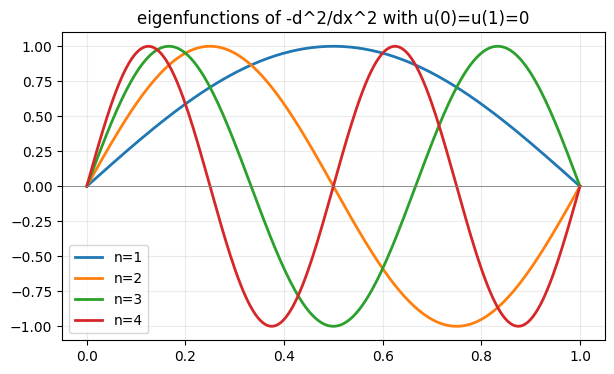

In [3]:
import numpy as np

# The first few Dirichlet eigenfunctions sin(n pi x / L) on [0, 1].
g = grids.Grid1D(0.0, 1.0, 200)
x = g.x
fig, ax = plt.subplots(figsize=(7, 4))
for n in (1, 2, 3, 4):
    ax.plot(x, datasets.sine_mode(x, mode=n, L=1.0), lw=2, label=f"n={n}")
ax.axhline(0, color="gray", lw=0.6)
ax.legend()
ax.grid(alpha=0.25)
ax.set_title("eigenfunctions of -d^2/dx^2 with u(0)=u(1)=0")
plt.show()

## 5. 熱方程式の解析解 (Applied)

熱方程式に変数分離を入れると、モード $n$ の時間部分は $T_n(t) = e^{-\alpha(n\pi/L)^2 t}$。
よって初期条件を固有関数で展開すれば、解は

$$
u(x, t) = \sum_n b_n\, e^{-\alpha (n\pi/L)^2 t}\,\sin\!\Big(\frac{n\pi x}{L}\Big)
$$

各モードが独立に減衰するだけ。この **解析解(級数和)** と、有限差分の **数値解** を重ねて一致を確認します。

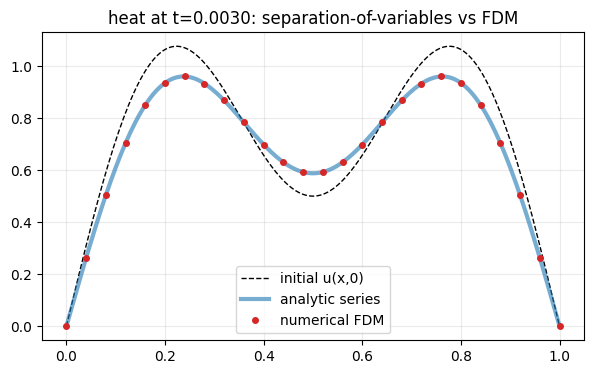

max |analytic - numerical| = 2.6863036057922507e-05


In [4]:
import numpy as np

# Analytic separation-of-variables series vs the numerical solver, for a 2-mode start.
g = grids.Grid1D(0.0, 1.0, 201)
x, dx = g.x, g.dx
alpha = 1.0
modes, amps = (1, 3), (1.0, 0.5)
u0 = datasets.sine_combo(x, modes, amps, L=1.0)

dt = 0.4 * dx**2 / alpha
steps = 300
U = solvers.solve_heat_explicit(u0, alpha, dx, dt, steps)
t_end = steps * dt
analytic = sum(
    a * np.exp(-alpha * (m * np.pi) ** 2 * t_end) * solvers.heat_mode_solution(x, 0, alpha, 1, m)
    for m, a in zip(modes, amps)
)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x, u0, "k--", lw=1, label="initial u(x,0)")
ax.plot(x, analytic, color="#1f77b4", lw=3, alpha=0.6, label="analytic series")
ax.plot(x[::8], U[-1][::8], "o", color="#d62728", ms=4, label="numerical FDM")
ax.legend()
ax.grid(alpha=0.25)
ax.set_title(f"heat at t={t_end:.4f}: separation-of-variables vs FDM")
plt.show()
print("max |analytic - numerical| =", float(np.max(np.abs(analytic - U[-1]))))

## 6. 波動方程式の解析解

同じ分解を波動方程式に行うと、時間部分は減衰せず **振動** します: $T_n(t) = \cos(n\pi c\,t/L)$。

$$
u(x, t) = \sum_n b_n \cos\!\Big(\frac{n\pi c t}{L}\Big)\sin\!\Big(\frac{n\pi x}{L}\Big)
$$

各モードが固有振動数 $n\pi c/L$ で振動——これが弦の **倍音(harmonics)** です。
単一モードの数値解が解析解 $\sin(n\pi x)\cos(n\pi c t)$ と一致することを見ます。

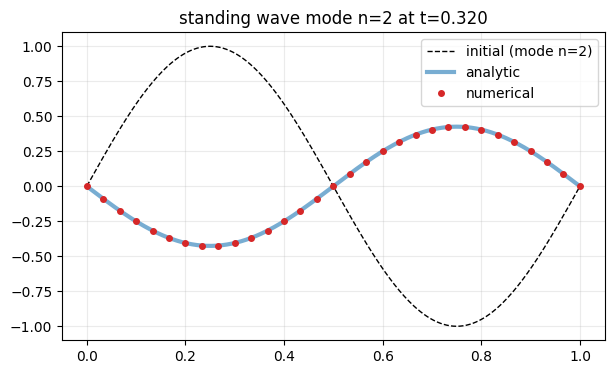

In [5]:
import numpy as np

# Wave: a single standing mode oscillates; numeric matches the analytic cos in time.
g = grids.Grid1D(0.0, 1.0, 301)
x, dx = g.x, g.dx
c, mode = 1.0, 2
dt = 0.8 * dx / c
steps = 120
u0 = solvers.wave_mode_solution(x, 0.0, c, L=1.0, mode=mode)
U = solvers.solve_wave(u0, np.zeros_like(x), c, dx, dt, steps)
t_end = steps * dt
analytic = solvers.wave_mode_solution(x, t_end, c, L=1.0, mode=mode)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x, u0, "k--", lw=1, label="initial (mode n=2)")
ax.plot(x, analytic, color="#1f77b4", lw=3, alpha=0.6, label="analytic")
ax.plot(x[::10], U[-1][::10], "o", color="#d62728", ms=4, label="numerical")
ax.legend()
ax.grid(alpha=0.25)
ax.set_title(f"standing wave mode n=2 at t={t_end:.3f}")
plt.show()

## 7. 線形代数との接続

固有関数 $\sin(n\pi x/L)$ は演算子 $-\partial_{xx}$ の固有ベクトル、$\lambda_n=(n\pi/L)^2$ は固有値です。
これは行列の対角化と同じ構造:**演算子を固有基底で見ると、各モードが独立に簡単な ODE になる**。
線形代数(固有値分解)と Fourier(波への分解)と PDE(変数分離)は、同じ一つの考えの別の顔です。

## Exercises

1. Neumann 条件($u_x(0)=u_x(L)=0$, 断熱端)では固有関数が $\cos(n\pi x/L)$ になることを示せ。
2. 熱方程式で初期条件を 3 モード混合にし、最後に残るのが最低次モードであることを級数解で確かめよ。
3. 弦の基本振動数 $\pi c/L$ を導き、弦を短く($L$ 小)すると音が高くなることを説明せよ。

## Advanced Notes

- **Sturm-Liouville 理論**: 一般の境界条件下でも、固有関数は直交完全系を成す。これが「展開できる」ことの保証。
- **直交性**: $\int_0^L \sin(n\pi x/L)\sin(m\pi x/L)\,dx = 0\ (n\ne m)$。係数 $b_n$ は内積(投影)で決まる。
- **非斉次・非分離**: 係数が場所に依る、または領域が長方形でない場合、変数分離は使えず数値解(06 章)に頼る。